<a href="https://colab.research.google.com/github/RithigaChandrasekar-0512/Weather-Prediction-and-Analysis/blob/main/Weather_prediction_and_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

from google.colab import files
uploaded = files.upload()

Saving seattle-weather.csv to seattle-weather.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df = pd.read_csv('seattle-weather.csv')

df.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [ ]:
print("Shape of Dataset:", df.shape)

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset: (1461, 6)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB
None

Missing Values:
date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64


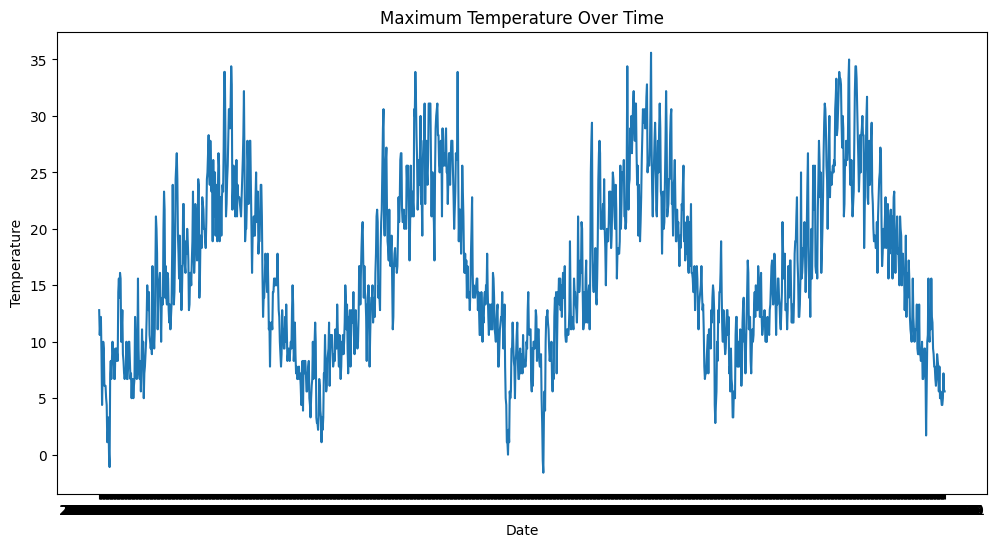

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df['date'], df['temp_max'])
plt.title('Maximum Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.show()

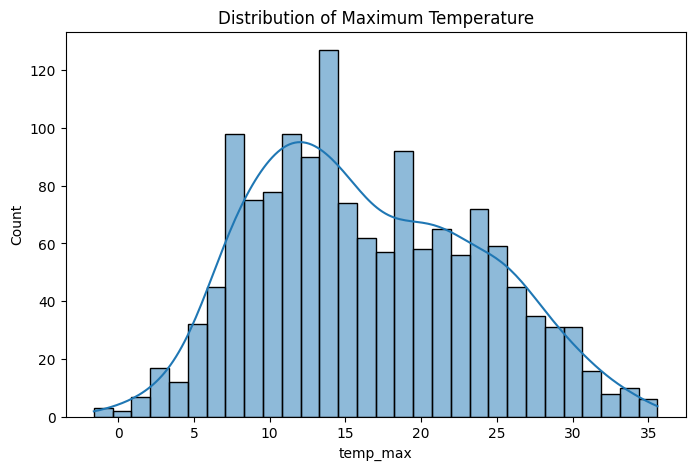

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['temp_max'], bins=30, kde=True)
plt.title("Distribution of Maximum Temperature")
plt.show()

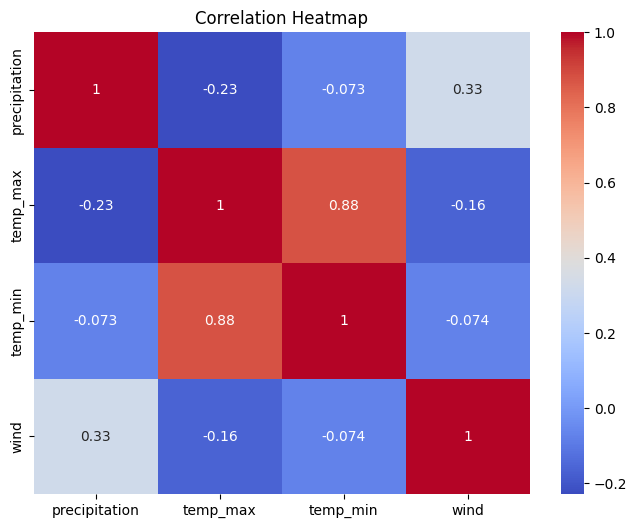

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

print(df.head())

        date  precipitation  temp_max  temp_min  wind  weather  year  month  \
0 2012-01-01            0.0      12.8       5.0   4.7  drizzle  2012      1   
1 2012-01-02           10.9      10.6       2.8   4.5     rain  2012      1   
2 2012-01-03            0.8      11.7       7.2   2.3     rain  2012      1   
3 2012-01-04           20.3      12.2       5.6   4.7     rain  2012      1   
4 2012-01-05            1.3       8.9       2.8   6.1     rain  2012      1   

   day  
0    1  
1    2  
2    3  
3    4  
4    5  


In [ ]:
X = df[['precipitation', 'temp_min', 'wind', 'year', 'month', 'day']]
y = df['temp_max']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [14]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

results.head()

,Actual,Predicted
892,23.9,20.860826
1105,7.8,14.624883
413,9.4,12.257621
522,26.7,22.331089
1036,13.3,15.427309


In [15]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 2.7062961050885552
MSE : 11.020542281156235
RMSE: 3.3197202112762807
R² Score: 0.8063444138211386


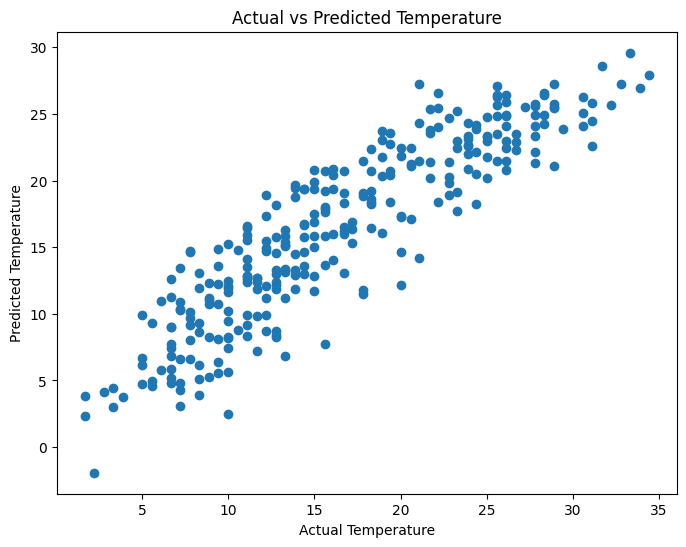

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Temperature")

plt.show()

In [18]:
future_data = pd.DataFrame({
    'precipitation':[2.0],
    'temp_min':[10.0],
    'wind':[3.5],
    'year':[2016],
    'month':[1],
    'day':[1]
})

prediction = model.predict(future_data)

print("Predicted Maximum Temperature:", prediction[0])

Predicted Maximum Temperature: 19.773510937857935
